# ADMM Residuals Plotting

This notebook plots primal and dual residuals from ADMM iteration output files.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def parse_padmm_file(filename):
    """
    Parse PADMM output file and extract iteration data.
    
    PADMM files have a format where multiple iterations can appear on a single line.
    Each iteration has 7 columns: Iter, Time, Objective, Prml Rsdl, Dual Rsdl, SNR, distance
    
    Returns:
        iterations: array of iteration numbers
        objectives: array of objective values
        primal_residuals: array of primal residuals
        dual_residuals: array of dual residuals
        snr: array of SNR values
        distance: array of distance values
    """
    iterations = []
    objectives = []
    primal_residuals = []
    dual_residuals = []
    snr = []
    distance = []
    
    with open(filename, 'r') as f:
        lines = f.readlines()
    
    # Find the header line
    header_found = False
    for i, line in enumerate(lines):
        if 'Iter' in line and 'Prml Rsdl' in line and 'Dual Rsdl' in line:
            header_found = True
            # Skip the separator line
            start_idx = i + 2
            break
    
    if not header_found:
        raise ValueError("Could not find header line in file")
    
    # Parse data lines
    for line in lines[start_idx:]:
        line = line.strip()
        
        # Skip empty lines
        if not line:
            continue
        
        # Skip lines that look like summary/end messages (e.g., "TV Restruction", "SNR:")
        if line.startswith('TV') or line.startswith('SNR:') or 'Restruction' in line:
            continue
        
        # Split the line into parts
        parts = line.split()
        
        # Each iteration has 7 columns: Iter, Time, Objective, Prml Rsdl, Dual Rsdl, SNR, distance
        # Process all iterations on this line (multiple iterations can be on one line)
        num_iterations = len(parts) // 7
        
        # Process each complete iteration (7 columns each)
        for i in range(num_iterations):
            start_col = i * 7
            end_col = start_col + 7
            
            if end_col > len(parts):
                break
            
            try:
                iter_parts = parts[start_col:end_col]
                
                # Column 0: iteration number
                iter_num = int(iter_parts[0])
                
                # Column 2: objective
                obj_str = iter_parts[2]
                if obj_str.lower() == 'inf':
                    obj = np.inf
                else:
                    obj = float(obj_str)
                
                # Column 3: primal residual
                primal = float(iter_parts[3])
                
                # Column 4: dual residual
                dual = float(iter_parts[4])
                
                # Column 5: SNR
                snr_val = float(iter_parts[5])
                
                # Column 6: distance
                dist_val = float(iter_parts[6])
                
                iterations.append(iter_num)
                objectives.append(obj)
                primal_residuals.append(primal)
                dual_residuals.append(dual)
                snr.append(snr_val)
                distance.append(dist_val)
                
            except (ValueError, IndexError) as e:
                # Skip this iteration if parsing fails
                continue
    
    return (np.array(iterations), np.array(objectives), np.array(primal_residuals), 
            np.array(dual_residuals), np.array(snr), np.array(distance))

In [3]:
def parse_admm_file(filename):
    """
    Parse ADMM output file and extract iteration data.
    
    Returns:
        iterations: array of iteration numbers
        objectives: array of objective values
        primal_residuals: array of primal residuals
        dual_residuals: array of dual residuals
        regularization: array of regularization term values
        constraint: array of constraint term values
    """
    iterations = []
    objectives = []
    primal_residuals = []
    dual_residuals = []
    regularization = []
    constraint = []
    
    with open(filename, 'r') as f:
        lines = f.readlines()
    
    # Find the header line
    header_found = False
    for i, line in enumerate(lines):
        if 'Iter' in line and 'Prml Rsdl' in line and 'Dual Rsdl' in line:
            header_found = True
            # Skip the separator line
            start_idx = i + 2
            break
    
    if not header_found:
        raise ValueError("Could not find header line in file")
    
    # Parse data lines
    for line in lines[start_idx:]:
        line = line.strip()
        
        # Skip empty lines and "τ is doubled" messages
        if not line or 'τ is doubled' in line:
            continue
        
        # Try to parse the line as a data row
        # Format: "  73  8.91e+01  4.755e+05  7.899e+03  3.760e+02  7.878e+03  1.220e+03"
        # Column order: Iter, Time, Objective, Prml Rsdl, Dual Rsdl, Regularization, Constraint
        parts = line.split()
        
        if len(parts) >= 5:
            try:
                # Column 0: iteration, Column 2: objective, Column 3: primal residual, Column 4: dual residual
                iter_num = int(parts[0])
                # Handle 'inf' for objective
                obj_str = parts[2]
                if obj_str.lower() == 'inf':
                    obj = np.inf
                else:
                    obj = float(obj_str)
                primal = float(parts[3])
                dual = float(parts[4])
                
                iterations.append(iter_num)
                objectives.append(obj)
                primal_residuals.append(primal)
                dual_residuals.append(dual)
                
                # Extract regularization and constraint if available (columns 5 and 6)
                if len(parts) >= 7:
                    regularization.append(float(parts[5]))
                    constraint.append(float(parts[6]))
                else:
                    regularization.append(np.nan)
                    constraint.append(np.nan)
            except (ValueError, IndexError):
                # Skip lines that don't match the expected format
                continue
    
    return np.array(iterations), np.array(objectives), np.array(primal_residuals), np.array(dual_residuals), np.array(regularization), np.array(constraint)

## Configuration

Specify the path to your ADMM output file:

In [4]:
# Update this path to point to your ADMM output file
SNR = "50"
num_views = "100"
# rho = "5e-1"
regularization_coeff = "2e0"
maxiter = "5000"
regularization_type = "tv"
Nx = 512
Nz = 512
Ny = 512
N_sphere = 100
save = False

In [5]:
rho_padmm = "5e-2"
input_file_padmm = f'results/ct_astra_3d_tv_padmm_fbp_initial_l2_plus_reg/ct_astra_3d_tv_padmm_l2_plus_reg_Nx512_Ny512_Nz512_sinogram_snr{SNR}_ρ5e-2_regularization2e0_n_projection100_maxiter5000.txt'
iterations_padmm, objectives_padmm, primal_residuals_padmm, dual_residuals_padmm, regularization_padmm, constraint_padmm = parse_padmm_file(input_file_padmm)

## Parse Data

In [6]:
# Moving average for smoother residual plots (adjust window to taste)
def moving_average(x, window):
    """Uniform moving average; same length as x (boundary uses partial window)."""
    return np.convolve(x, np.ones(window) / window, mode="same")

In [7]:
smooth_window = 100

In [8]:
import re

def parse_results_txt(results_path):
    """
    Parse results.txt (appended test logs) and return a dict mapping
    (rho, maxiter_pdhg) -> (snr, mae).
    """
    out = {}
    try:
        with open(results_path, "r") as f:
            lines = f.readlines()
    except FileNotFoundError:
        return out
    i = 0
    while i < len(lines):
        line = lines[i]
        if not line.strip().startswith("Test configuration:"):
            i += 1
            continue
        config_line = line.strip()
        i += 1
        if i >= len(lines):
            break
        snr_line = lines[i].strip()
        if "Final SNR:" not in snr_line:
            i += 1
            continue
        # Parse config: "Test configuration: Nx: 512, ... rho: 0.5, ... maxiter_pdhg: 50"
        config_str = config_line.replace("Test configuration:", "").strip()
        params = {}
        for part in config_str.split(", "):
            if ": " in part:
                k, v = part.split(": ", 1)
                k, v = k.strip(), v.strip()
                try:
                    if "." in v:
                        params[k] = float(v)
                    else:
                        params[k] = int(v)
                except ValueError:
                    params[k] = v
        # Parse "Final SNR: 27.43 (dB), Final MAE: 0.002..."
        snr_match = re.search(r"Final SNR:\s*([\d.]+)", snr_line)
        mae_match = re.search(r"Final MAE:\s*([\d.e+-]+)", snr_line)
        snr_val = float(snr_match.group(1)) if snr_match else None
        mae_val = float(mae_match.group(1)) if mae_match else None
        # Key is (rho, maxiter_pdhg)
        rho = params.get("rho")
        maxiter_pdhg = params.get("maxiter_pdhg")
        if rho is not None and maxiter_pdhg is not None:
            out[(rho, maxiter_pdhg)] = (snr_val, mae_val)
        i += 1
    return out

# Build SNR/MAE lookup from results.txt (same folder as per-run ADMM files)
folder_name = f"results/semi_pjadmm_parallel_tv_fbp_noisy_sinogram_snr{SNR}_2_2_N_sphere{N_sphere}_l2_plus_reg_iterative_reg_estimated_pdhg"
results_path = f"{folder_name}/results.txt"
snr_mae_from_results = parse_results_txt(results_path)
snr_mae_list = {}

In [9]:
info_list = {}
# Load the parameter tuning session
for MAXITER_PDHG in ["50", "10", "5"]:
    for RHO in ["5e-2", "5e-1", "5e0", "5e1"]:
        folder_name = f"results/semi_pjadmm_parallel_tv_fbp_noisy_sinogram_snr{SNR}_2_2_N_sphere{N_sphere}_l2_plus_reg_iterative_reg_estimated_pdhg"
        file_name = f"{folder_name}/ct_mbirjax_3d_tv_semi_pjadmm_l2_plus_reg_iterative_reg_estimated_pdhg_Nx{Nx}_Ny{Ny}_Nz{Nz}_sinogram_snr{SNR}_ρ{RHO}_regularization2e0_n_projection{num_views}_maxiter{maxiter}_maxiter_pdhg{MAXITER_PDHG}.txt"
        iterations_record, objectives_record, primal_residuals_record, dual_residuals_record, regularization_record, constraint_record = parse_admm_file(file_name)
        primal_residuals_smooth_record = moving_average(primal_residuals_record, smooth_window)
        dual_residuals_smooth_record = moving_average(dual_residuals_record, smooth_window)

        # Look up final SNR and MAE from results.txt using (rho, maxiter_pdhg)
        key_lookup = (float(RHO), int(MAXITER_PDHG))
        final_snr, final_mae = snr_mae_from_results.get(key_lookup, (None, None))
        
        info_list[(RHO, MAXITER_PDHG)] = [iterations_record, objectives_record, primal_residuals_record, dual_residuals_record, regularization_record, constraint_record, primal_residuals_smooth_record, dual_residuals_smooth_record, final_snr, final_mae]


In [10]:
def analyze_convergence(values, name="values"):
    """
    Analyze whether a sequence is decreasing and report statistics.
    """
    values = np.array(values)
    n = len(values)
    if n < 2:
        print(f"{name}: Not enough data points")
        return
    
    # Overall trend: compare first and last values
    start_val = values[0]
    end_val = values[-1]
    overall_decrease = (end_val < start_val)
    ratio = end_val / start_val if start_val != 0 else float('inf')
    
    # Count decreasing steps
    diffs = np.diff(values)
    decreasing_steps = np.sum(diffs < 0)
    pct_decreasing = 100 * decreasing_steps / (n - 1)
    
    # Fit linear regression to log values (for exponential decay check)
    log_values = np.log(values[values > 0])
    if len(log_values) > 1:
        x = np.arange(len(log_values))
        slope, intercept = np.polyfit(x, log_values, 1)
        decay_rate = -slope  # positive = decreasing
    else:
        decay_rate = None
    
    print(f"\n{name}:")
    print(f"  Start: {start_val:.6e}, End: {end_val:.6e}")
    print(f"  Overall decreasing: {overall_decrease} (ratio end/start = {ratio:.4f})")
    print(f"  Decreasing steps: {decreasing_steps}/{n-1} ({pct_decreasing:.1f}%)")
    if decay_rate is not None:
        print(f"  Log-linear slope: {-decay_rate:.6f} ({'decreasing' if decay_rate > 0 else 'increasing'})")
    
    return overall_decrease, pct_decreasing, decay_rate

In [11]:
starting_index_decreament_test = 4000
end_index_decreament_test = 4500
# Analyze convergence for each configuration
print("=" * 60)
print("CONVERGENCE ANALYSIS")
print("=" * 60)
for key, value in info_list.items():
    rho, MAXITER_PDHG_temp = key
    iterations_temp, objectives_temp, primal_residuals_temp, dual_residuals_temp, regularization_temp, constraint_temp, primal_residuals_smooth_temp, dual_residuals_smooth_temp, final_snr_temp, final_mae_temp = value
    
    print(f"\n{'='*60}")
    print(f"Config: ρ={rho}, maxiter_pdhg={MAXITER_PDHG_temp}")
    print(f"{'='*60}")
    
    analyze_convergence(primal_residuals_smooth_temp[starting_index_decreament_test:end_index_decreament_test], "Primal Residuals (smoothed)")
    analyze_convergence(dual_residuals_smooth_temp[starting_index_decreament_test:end_index_decreament_test], "Dual Residuals (smoothed)")

CONVERGENCE ANALYSIS

Config: ρ=5e-2, maxiter_pdhg=50

Primal Residuals (smoothed):
  Start: 4.048700e+00, End: 3.953070e+00
  Overall decreasing: True (ratio end/start = 0.9764)
  Decreasing steps: 281/499 (56.3%)
  Log-linear slope: -0.000023 (decreasing)

Dual Residuals (smoothed):
  Start: 1.677268e+01, End: 1.450054e+01
  Overall decreasing: True (ratio end/start = 0.8645)
  Decreasing steps: 256/499 (51.3%)
  Log-linear slope: -0.000208 (decreasing)

Config: ρ=5e-1, maxiter_pdhg=50

Primal Residuals (smoothed):
  Start: 8.317160e-01, End: 5.410960e-01
  Overall decreasing: True (ratio end/start = 0.6506)
  Decreasing steps: 260/499 (52.1%)
  Log-linear slope: -0.000256 (decreasing)

Dual Residuals (smoothed):
  Start: 1.481640e+02, End: 8.515963e+01
  Overall decreasing: True (ratio end/start = 0.5748)
  Decreasing steps: 259/499 (51.9%)
  Log-linear slope: -0.000302 (decreasing)

Config: ρ=5e0, maxiter_pdhg=50

Primal Residuals (smoothed):
  Start: 2.543223e-01, End: 2.405042e-0

## Plot Residuals

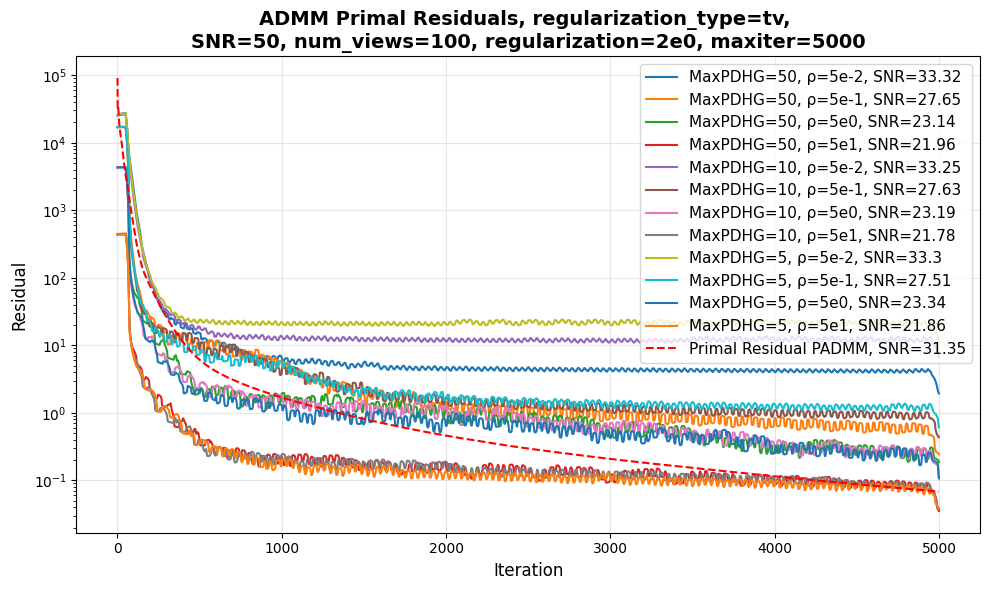

In [12]:
# Primal residual plotting block
plt.figure(figsize=(10, 6))

'''
PJADMM Part
'''
for key, value in info_list.items():
    rho, MAXITER_PDHG_temp = key
    iterations_temp, objectives_temp, primal_residuals_temp, dual_residuals_temp, regularization_temp, constraint_temp, primal_residuals_smooth_temp, dual_residuals_smooth_record, final_snr_temp, final_mae_temp = value
    plt.semilogy(iterations_temp[1:], primal_residuals_smooth_temp[1:], label=f'MaxPDHG={MAXITER_PDHG_temp}, ρ={rho}, SNR={round(final_snr_temp, 2)}', linewidth=1.5)

'''
PADMM Part
'''
plt.semilogy(iterations_padmm[1:], primal_residuals_padmm[1:], 'r--', label='Primal Residual PADMM, SNR=31.35', linewidth=1.5)

'''
Plot Configs
'''
plt.xlabel('Iteration', fontsize=12)
plt.ylabel('Residual', fontsize=12)
plt.title(f'ADMM Primal Residuals, regularization_type={regularization_type}, \nSNR={SNR}, num_views={num_views}, regularization={regularization_coeff}, maxiter={maxiter}', fontsize=14, fontweight='bold')

plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)

# Set y-axis ticks to be every 10^n
from matplotlib.ticker import LogLocator
ax = plt.gca()
plt.tight_layout()

if save:
    output_file = f"results/residual_plots/semi_pjadmm_residuals_regularization_type{regularization_type}_Nx{Nx}_Ny{Ny}_Nz{Nz}_snr{SNR}_num_views{num_views}_rho{rho}_regularization{regularization_coeff}_maxiter{maxiter}_l2_plus_reg.png"
    plt.savefig(output_file, dpi=300, bbox_inches='tight')
    print(f"Plot saved to {output_file}")

plt.show()

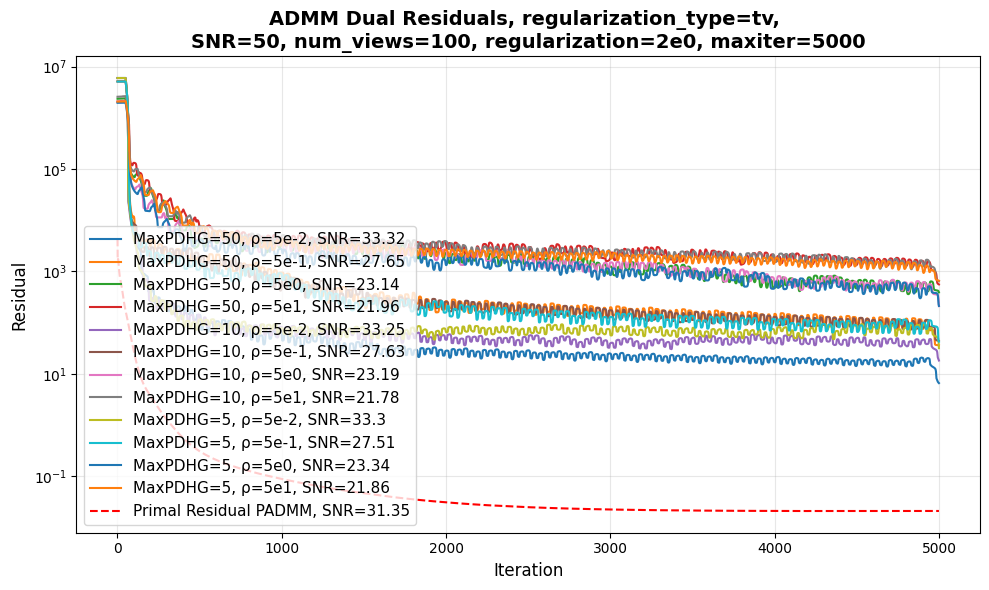

In [13]:
# Primal residual plotting block
plt.figure(figsize=(10, 6))

'''
PJADMM Part
'''
for key, value in info_list.items():
    rho, MAXITER_PDHG_temp = key
    iterations_temp, objectives_temp, primal_residuals_temp, dual_residuals_temp, regularization_temp, constraint_temp, primal_residuals_smooth_temp, dual_residuals_smooth_temp, final_snr_temp, final_mae_temp = value
    plt.semilogy(iterations_temp[1:], dual_residuals_smooth_temp[1:], label=f'MaxPDHG={MAXITER_PDHG_temp}, ρ={rho}, SNR={round(final_snr_temp, 2)}', linewidth=1.5)

'''
PADMM Part
'''
plt.semilogy(iterations_padmm[1:], dual_residuals_padmm[1:], 'r--', label='Primal Residual PADMM, SNR=31.35', linewidth=1.5)

'''
Plot Configs
'''
plt.xlabel('Iteration', fontsize=12)
plt.ylabel('Residual', fontsize=12)
plt.title(f'ADMM Dual Residuals, regularization_type={regularization_type}, \nSNR={SNR}, num_views={num_views}, regularization={regularization_coeff}, maxiter={maxiter}', fontsize=14, fontweight='bold')

plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)

# Set y-axis ticks to be every 10^n
from matplotlib.ticker import LogLocator
ax = plt.gca()
plt.tight_layout()

if save:
    output_file = f"results/residual_plots/semi_pjadmm_residuals_regularization_type{regularization_type}_Nx{Nx}_Ny{Ny}_Nz{Nz}_snr{SNR}_num_views{num_views}_rho{rho}_regularization{regularization_coeff}_maxiter{maxiter}_l2_plus_reg.png"
    plt.savefig(output_file, dpi=300, bbox_inches='tight')
    print(f"Plot saved to {output_file}")

plt.show()

Final ratio is 1.1306916071868078
Final ratio is 1.1329067191730249
Final ratio is 1.153334974157027
Final ratio is 1.1757322175732217
Final ratio is 1.126999753876446
Final ratio is 1.1304454836327837
Final ratio is 1.151612109278858
Final ratio is 1.1742554762490771
Final ratio is 1.1122323406349988
Final ratio is 1.1238001476741324
Final ratio is 1.1466896381983755
Final ratio is 1.1644105340881121


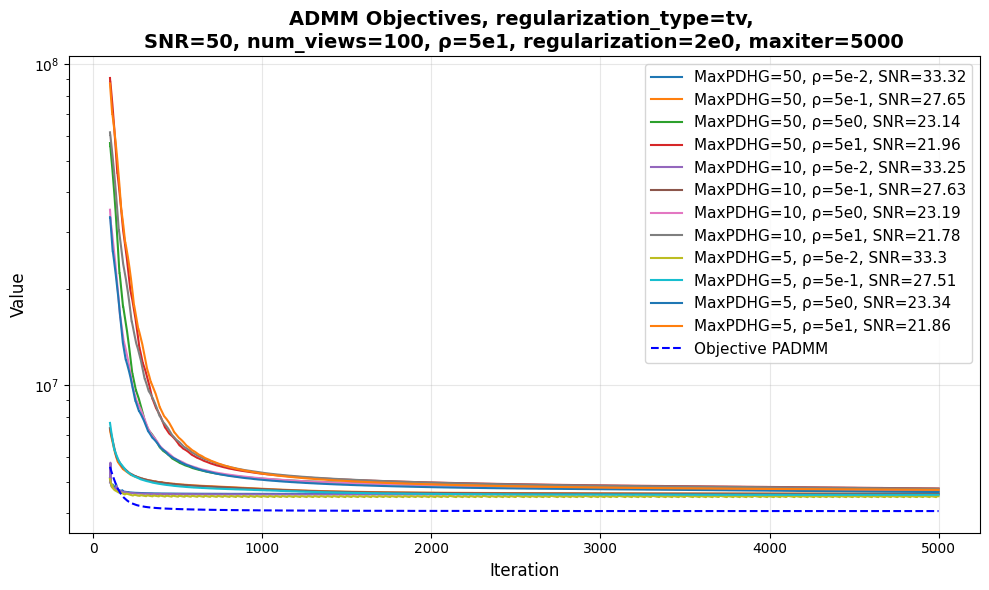

In [14]:
# TODO: Check why the initial objectives are drastically different.
# TODO: Run for more iterations...

# Plot Objectives, Regularization, and Constraint
plt.figure(figsize=(10, 6))
start_index = 100

# Filter out inf values for plotting
valid_mask_padmm = (objectives_padmm != np.inf) & (objectives_padmm > 0)
# valid_mask_prox = (objectives_prox != np.inf) & (objectives_prox > 0)

# plt.plot(iterations[valid_mask][start_index:], objectives[valid_mask][start_index:], 'g--', label='Objective PJADMM', linewidth=1.5)

for key, value in info_list.items():
    rho, MAXITER_PDHG_temp = key
    iterations_temp, objectives_temp, primal_residuals_temp, dual_residuals_temp, regularization_temp, constraint_temp, primal_residuals_smooth_temp, dual_residuals_smooth_temp, final_snr_temp, final_mae_temp = value
    plt.semilogy(iterations_temp[start_index:], objectives_temp[start_index:], label=f'MaxPDHG={MAXITER_PDHG_temp}, ρ={rho}, SNR={round(final_snr_temp, 2)}', linewidth=1.5)
    print("Final ratio is", objectives_temp[-1] / objectives_padmm[-1])

plt.semilogy(iterations_padmm[valid_mask_padmm][start_index:], objectives_padmm[valid_mask_padmm][start_index:], 'b--', label='Objective PADMM', linewidth=1.5)

# plt.plot(iterations_prox[valid_mask_prox][start_index:], objectives_prox[valid_mask_prox][start_index:], 'g-', label='Objective PJADMM Proximal Comparison', linewidth=1.5)

# plt.axhline(y=true_objective, color='r', linestyle='-', label='True Objective', linewidth=1.5)
# print("True objective:", true_objective)

# # Plot regularization and constraint terms if available
# if not np.all(np.isnan(regularization)):
#     reg_valid_mask = valid_mask & ~np.isnan(regularization) & (regularization > 0)
#     if np.any(reg_valid_mask):
#         plt.plot(iterations[reg_valid_mask][start_index:], regularization[reg_valid_mask][start_index:], 'b-', label='Regularization', linewidth=1.5)

# if not np.all(np.isnan(constraint)):
#     const_valid_mask = valid_mask & ~np.isnan(constraint) & (constraint > 0)
#     if np.any(const_valid_mask):
#         plt.plot(iterations[const_valid_mask][start_index:], constraint[const_valid_mask][start_index:], 'r-', label='Constraint', linewidth=1.5)

plt.xlabel('Iteration', fontsize=12)
plt.ylabel('Value', fontsize=12)
plt.title(f'ADMM Objectives, regularization_type={regularization_type}, \nSNR={SNR}, num_views={num_views}, ρ={rho}, regularization={regularization_coeff}, maxiter={maxiter}', fontsize=14, fontweight='bold')

plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)

plt.tight_layout()

if save:
    output_file = f"results/residual_plots/semi_pjadmm_objectives_regularization_type{regularization_type}_Nx{Nx}_Ny{Ny}_Nz{Nz}_snr{SNR}_num_views{num_views}_rho{rho}_regularization{regularization_coeff}_maxiter{maxiter}.png"
    plt.savefig(output_file, dpi=300, bbox_inches='tight')
    print(f"Plot saved to {output_file}")

plt.show()

In [15]:
# TODO: Plot a log-Y plot that shows the difference between best PJADMM (eg. 2000 iterations)
# and the PADMM objective. Or maybe quotient?

# Plot Objectives, Regularization, and Constraint
plt.figure(figsize=(10, 6))
start_index = 100

# Filter out inf values for plotting
valid_mask = (objectives != np.inf) & (objectives > 0)

final_padmm_objective = objectives_padmm[-1]
plt.plot(iterations[valid_mask][start_index:], objectives[valid_mask][start_index:] / final_padmm_objective, 'b--', label='Objective Ratio', linewidth=1.5)
print("Final objective ratio:", objectives[valid_mask][-1] / final_padmm_objective)

plt.axhline(y=1, color='r', linestyle='-', label='Ratio=1', linewidth=1.5)

plt.xlabel('Iteration', fontsize=12)
plt.ylabel('Value', fontsize=12)
plt.title(f'ADMM Objective, Regularization, and Constraint, regularization_type={regularization_type}, \nSNR={SNR}, num_views={num_views}, ρ={rho}, regularization={regularization_coeff}, maxiter={maxiter}', fontsize=14, fontweight='bold')

plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)

plt.tight_layout()

if save:
    output_file = f"results/residual_plots/semi_pjadmm_objectives_regularization_type{regularization_type}_Nx{Nx}_Ny{Ny}_Nz{Nz}_snr{SNR}_num_views{num_views}_rho{rho}_regularization{regularization_coeff}_maxiter{maxiter}.png"
    plt.savefig(output_file, dpi=300, bbox_inches='tight')
    print(f"Plot saved to {output_file}")

plt.show()

NameError: name 'objectives' is not defined

<Figure size 1000x600 with 0 Axes>